In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Install Libraries
# ─────────────────────────────────────────────────────────────────────────────
# Run once at the start
 
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q lightgbm xgboost tensorflow
!pip install -q requests openpyxl statsmodels
 
print("✓ All libraries installed")

✓ All libraries installed


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Imports
# ─────────────────────────────────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')
 
# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
 
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
 
# Statistics
from scipy import stats
 
print("✓ All imports successful")
print(f"  TensorFlow : {tf.__version__}")
print(f"  XGBoost    : {xgb.__version__}")
print(f"  LightGBM   : {lgb.__version__}")
 
 


2026-05-11 10:00:14.694491: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 10:00:14.694545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 10:00:14.695968: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ All imports successful
  TensorFlow : 2.15.0
  XGBoost    : 2.0.3
  LightGBM   : 4.2.0


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Helper Functions  ← DEFINE BEFORE EVERYTHING ELSE
# ─────────────────────────────────────────────────────────────────────────────
 
def calculate_metrics(y_true, y_pred, name="Model"):
    mask = y_true > 10
    yt = y_true[mask]
    yp = y_pred[mask]

    rmse  = np.sqrt(mean_squared_error(yt, yp))
    nrmse = rmse / (yt.max() - yt.min()) * 100
    mae   = mean_absolute_error(yt, yp)
    mbe   = np.mean(yp - yt)
    r2    = r2_score(yt, yp)

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  RMSE   : {rmse:.2f} W")
    print(f"  nRMSE  : {nrmse:.2f} %")
    print(f"  MAE    : {mae:.2f} W")
    print(f"  MBE    : {mbe:.2f} W")
    print(f"  R²     : {r2:.4f}")

    return {
        "RMSE (W)"  : rmse,
        "nRMSE (%)" : nrmse,
        "MAE (W)"   : mae,
        "MBE (W)"   : mbe,
        "R2"        : r2,
        "RMSE"      : rmse,
        "MAE"       : mae,
        "nRMSE"     : nrmse,
    }
 
 
def diebold_mariano_test(y_true, y_pred1, y_pred2, loss="squared"):
    """
    Diebold-Mariano test: H0 = no difference in forecast accuracy.
    Returns (DM statistic, p-value).
    loss: 'squared' or 'absolute'
    """
    if loss == "squared":
        e1 = (y_true - y_pred1) ** 2
        e2 = (y_true - y_pred2) ** 2
    else:
        e1 = np.abs(y_true - y_pred1)
        e2 = np.abs(y_true - y_pred2)
 
    d = e1 - e2
    n = len(d)
    mean_d = np.mean(d)
 
    # Newey-West variance with lag h=1
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[:-1], d[1:])[0, 1]
    var_d  = (gamma0 + 2 * gamma1) / n
    var_d  = max(var_d, 1e-10)   # avoid division by zero
 
    dm_stat = mean_d / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value
 
 
def physics_power(ghi, temp, panel_area=50, eta=0.20,
                  inv_eff=0.95, soiling=0.98):
    """Convert GHI + temperature to AC power using physical model."""
    panel_temp  = temp + 0.03 * ghi
    temp_factor = (1 - 0.004 * (panel_temp - 25)).clip(0.70, 1.05)
    power       = ghi * panel_area * eta * inv_eff * soiling * temp_factor
    power       = np.where(ghi < 10, 0, power)
    return power.clip(0)
 
 
print("✓ All helper functions defined")


✓ All helper functions defined


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Download NASA POWER Data
# ─────────────────────────────────────────────────────────────────────────────
 
def download_nasa_power(lat, lon, start, end, name):
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    params = {
        "parameters" : "ALLSKY_SFC_SW_DWN,T2M,RH2M,WS2M,PS",
        "community"  : "RE",
        "longitude"  : lon,
        "latitude"   : lat,
        "start"      : start,
        "end"        : end,
        "format"     : "JSON",
        "time_standard": "UTC",
    }
    print(f"  Downloading {name} ...", end=" ")
    r = requests.get(url, params=params, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"NASA POWER API error {r.status_code} for {name}")
 
    p  = r.json()["properties"]["parameter"]
    df = pd.DataFrame({k: pd.Series(v) for k, v in p.items()})
    df.index = pd.to_datetime(df.index.astype(str), format="%Y%m%d%H")
    df = df.rename(columns={
        "ALLSKY_SFC_SW_DWN": "GHI",
        "T2M"               : "Temperature",
        "RH2M"              : "Humidity",
        "WS2M"              : "WindSpeed",
        "PS"                : "Pressure",
    })
    df = df.replace(-999, np.nan).dropna()
    df["Location"] = name
    print(f"done → {df.shape}")
    return df
 
 
print("Fetching data …")
df_berlin  = download_nasa_power(52.52,  13.405,   "20210101", "20211231", "Berlin")
df_phoenix = download_nasa_power(33.4484, -112.074, "20210101", "20211231", "Phoenix")
 
df = pd.concat([df_berlin, df_phoenix]).sort_index()
print(f"\n✓ Combined dataset: {df.shape}")
print(f"  Locations: {df['Location'].unique().tolist()}")



Fetching data …

✓ Combined dataset: (17520, 6)
  Locations: ['Berlin', 'Phoenix']


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: Feature Engineering  (done ONCE, cleanly)
# ─────────────────────────────────────────────────────────────────────────────
 
print("Building features …")
 
# Time features
df["hour"]       = df.index.hour
df["month"]      = df.index.month
df["day_of_year"]= df.index.dayofyear
 
# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"]  = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"]  = np.cos(2 * np.pi * df["day_of_year"] / 365)
 
# Lag features for temperature (grouped by location to avoid bleed)
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"Temp_lag_{lag}"] = df.groupby("Location")["Temperature"].shift(lag)
 
# Interaction features
df["Temp_Humidity"]  = df["Temperature"] * df["Humidity"] / 100
df["Wind_Pressure"]  = df["WindSpeed"]   * df["Pressure"]
 
# Physics-based columns
df["Panel_Temp"]   = df["Temperature"] + 0.03 * df["GHI"]
df["Temp_factor"]  = (1 - 0.004 * (df["Panel_Temp"] - 25)).clip(0.70, 1.05)
 
# Target: Physics AC power (ground truth for a 50 m² array)
df["Power_AC"] = physics_power(
    df["GHI"].values, df["Temperature"].values
)
 
# Drop NaN rows introduced by lags
df = df.dropna()
 
print(f"✓ Feature engineering done → {df.shape}")
print(f"  Columns: {df.columns.tolist()}")



Building features …
✓ Feature engineering done → (17472, 24)
  Columns: ['GHI', 'Temperature', 'Humidity', 'WindSpeed', 'Pressure', 'Location', 'hour', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'Temp_lag_1', 'Temp_lag_2', 'Temp_lag_3', 'Temp_lag_6', 'Temp_lag_12', 'Temp_lag_24', 'Temp_Humidity', 'Wind_Pressure', 'Panel_Temp', 'Temp_factor', 'Power_AC']


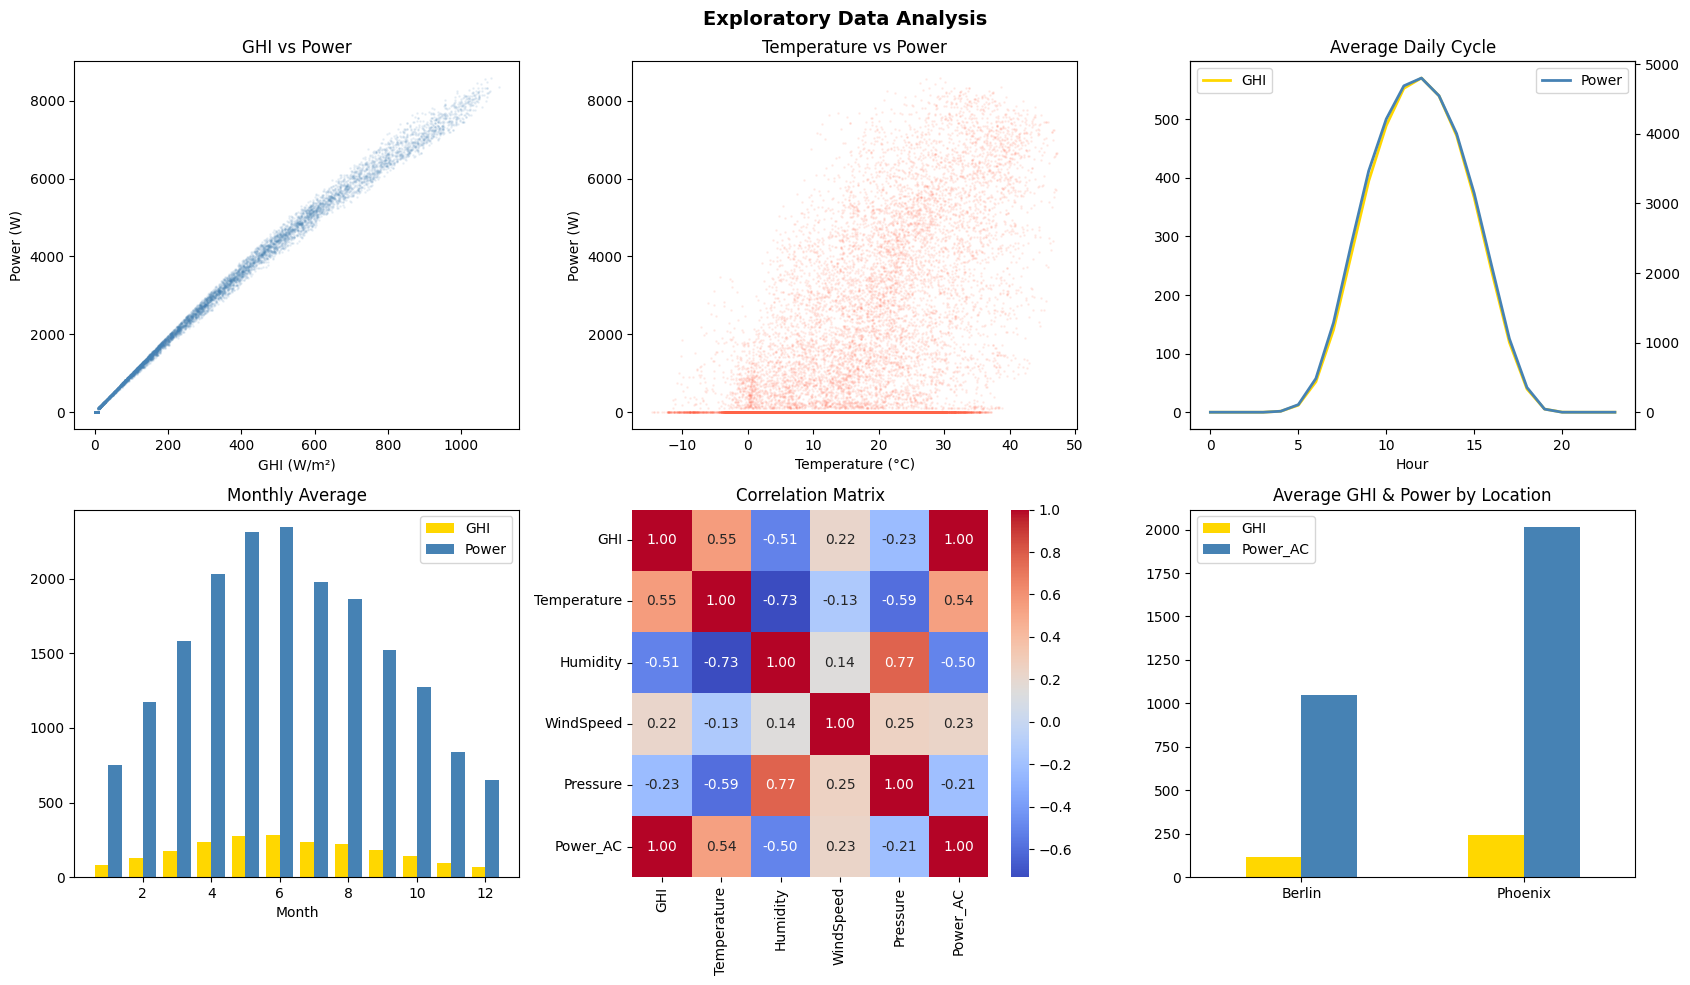

✓ EDA saved as eda_plots.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: Exploratory Visualisation
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold")
 
# GHI vs Power
axes[0,0].scatter(df["GHI"], df["Power_AC"], alpha=0.08, s=1, c="steelblue")
axes[0,0].set(xlabel="GHI (W/m²)", ylabel="Power (W)", title="GHI vs Power")
 
# Temperature vs Power
axes[0,1].scatter(df["Temperature"], df["Power_AC"], alpha=0.08, s=1, c="tomato")
axes[0,1].set(xlabel="Temperature (°C)", ylabel="Power (W)", title="Temperature vs Power")
 
# Daily cycle
hourly = df.groupby("hour")[["GHI", "Power_AC"]].mean()
ax2 = axes[0,2].twinx()
axes[0,2].plot(hourly["GHI"],      label="GHI",   color="gold",      lw=2)
ax2.plot(      hourly["Power_AC"], label="Power", color="steelblue", lw=2)
axes[0,2].set(xlabel="Hour", title="Average Daily Cycle")
axes[0,2].legend(loc="upper left"); ax2.legend(loc="upper right")
 
# Monthly cycle
monthly = df.groupby("month")[["GHI", "Power_AC"]].mean()
axes[1,0].bar(monthly.index - 0.2, monthly["GHI"],      0.4, label="GHI",   color="gold")
axes[1,0].bar(monthly.index + 0.2, monthly["Power_AC"], 0.4, label="Power", color="steelblue")
axes[1,0].set(xlabel="Month", title="Monthly Average"); axes[1,0].legend()
 
# Correlation heat-map
corr_cols = ["GHI","Temperature","Humidity","WindSpeed","Pressure","Power_AC"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")
 
# Location comparison
loc_stats = df.groupby("Location")[["GHI","Power_AC"]].mean()
loc_stats.plot(kind="bar", ax=axes[1,2], color=["gold","steelblue"])
axes[1,2].set(title="Average GHI & Power by Location", xticklabels=loc_stats.index,
              xlabel="")
axes[1,2].tick_params(axis="x", rotation=0)
 
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("✓ EDA saved as eda_plots.png")
 
 


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: Train / Test Split  (temporal — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
 
SPLIT_DATE = "2021-07-01"
 
df = df.sort_index()
train_all = df[df.index <  SPLIT_DATE].copy()
test_all  = df[df.index >= SPLIT_DATE].copy()
 
print("="*50)
print("TRAIN / TEST SPLIT")
print("="*50)
print(f"  Train: {train_all.index.min().date()} → {train_all.index.max().date()}"
      f"  ({len(train_all):,} samples)")
print(f"  Test : {test_all.index.min().date()} → {test_all.index.max().date()}"
      f"  ({len(test_all):,} samples)")
print("✓ Split created")

TRAIN / TEST SPLIT
  Train: 2021-01-02 → 2021-06-30  (8,640 samples)
  Test : 2021-07-01 → 2021-12-31  (8,832 samples)
✓ Split created


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: METHOD A — Direct ML  (Weather → Power_AC)
# No GHI, no physics — pure black-box baseline
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("METHOD A: Direct ML  (Weather → Power_AC)")
print("="*60)
 
FEATURES_A = [
    "Temperature", "Humidity", "WindSpeed", "Pressure",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "Temp_lag_1", "Temp_lag_6", "Temp_lag_24",
    "Temp_Humidity", "Wind_Pressure",
]
TARGET = "Power_AC"
 
X_train_a = train_all[FEATURES_A]
y_train_a = train_all[TARGET]
X_test_a  = test_all[FEATURES_A]
y_test_a  = test_all[TARGET].values
 
model_a = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)
model_a.fit(
    X_train_a, y_train_a,
    eval_set=[(X_test_a, y_test_a)],
    verbose=False,
)
 
y_pred_a = np.maximum(model_a.predict(X_test_a), 0)
metrics_a = calculate_metrics(y_test_a, y_pred_a, "Method A — Direct XGBoost")
 
# Feature importance
feat_imp_a = pd.Series(model_a.feature_importances_, index=FEATURES_A)
print("\nTop-5 features (Method A):")
print(feat_imp_a.sort_values(ascending=False).head())
print("✓ Method A completed")
 


METHOD A: Direct ML  (Weather → Power_AC)

────────────────────────────────────────
  Method A — Direct XGBoost
────────────────────────────────────────
  RMSE   : 879.96 W
  nRMSE  : 11.63 %
  MAE    : 662.19 W
  MBE    : 92.18 W
  R²     : 0.8181

Top-5 features (Method A):
hour_cos       0.663733
Humidity       0.095228
Temperature    0.066926
Temp_lag_6     0.054422
doy_cos        0.037214
dtype: float32
✓ Method A completed


In [9]:
 
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: METHOD B — Two-Stage Physics-Informed
# Stage 1: LightGBM forecasts GHI from weather
# Stage 2: Physics model converts GHI_pred → Power_AC
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("METHOD B: Two-Stage  (Weather → GHI → Physics → Power)")
print("="*60)
 
# ── Stage 1: predict GHI ──────────────────────────────────────────────────
FEATURES_B = [
    "Temperature", "Humidity", "WindSpeed", "Pressure",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "Temp_lag_1", "Temp_lag_6", "Temp_lag_24",
]
 
X_train_b = train_all[FEATURES_B]
y_train_b = train_all["GHI"]
X_test_b  = test_all[FEATURES_B]
 
model_b_ghi = lgb.LGBMRegressor(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
model_b_ghi.fit(
    X_train_b, y_train_b,
    eval_set=[(X_test_b, test_all["GHI"])],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(-1)],
)
 
ghi_pred_b = np.maximum(model_b_ghi.predict(X_test_b), 0)
 
# Stage 1 diagnostics
ghi_true   = test_all["GHI"].values
rmse_ghi   = np.sqrt(mean_squared_error(ghi_true, ghi_pred_b))
r2_ghi     = r2_score(ghi_true, ghi_pred_b)
print(f"\nStage 1 — GHI prediction: RMSE={rmse_ghi:.2f} W/m²  R²={r2_ghi:.4f}")
 
# ── Stage 2: physics model ─────────────────────────────────────────────────
y_pred_b   = physics_power(ghi_pred_b, test_all["Temperature"].values)
y_test_b   = test_all[TARGET].values
metrics_b  = calculate_metrics(y_test_b, y_pred_b, "Method B — Two-Stage Physics")
 
print("✓ Method B completed")
 
 


METHOD B: Two-Stage  (Weather → GHI → Physics → Power)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2187
[LightGBM] [Info] Number of data points in the train set: 8640, number of used features: 11
[LightGBM] [Info] Start training from score 197.666477
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

METHOD C: Hybrid LSTM  (Physics + Weather → Power)
  LSTM shapes  train=(8616, 24, 9)  test=(8808, 24, 9)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 24, 256)           141312    
 al)                                                             
                                                                 
 batch_normalization (Batch  (None, 24, 256)           1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 24, 256)           0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 128)               164352    
 onal)                                                           
                                                                 
 batch_normaliza

I0000 00:00:1778493647.820341    1640 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


115/115 [==============================] - 12s 24ms/step - loss: 0.1227 - mae: 0.2595 - val_loss: 0.1028 - val_mae: 0.2262 - lr: 0.0010
Epoch 2/80
115/115 [==============================] - 1s 13ms/step - loss: 0.0371 - mae: 0.1473 - val_loss: 0.0662 - val_mae: 0.1803 - lr: 0.0010
Epoch 3/80
115/115 [==============================] - 2s 13ms/step - loss: 0.0264 - mae: 0.1206 - val_loss: 0.0411 - val_mae: 0.1370 - lr: 0.0010
Epoch 4/80
115/115 [==============================] - 1s 13ms/step - loss: 0.0211 - mae: 0.1057 - val_loss: 0.0192 - val_mae: 0.0951 - lr: 0.0010
Epoch 5/80
115/115 [==============================] - 1s 13ms/step - loss: 0.0183 - mae: 0.0961 - val_loss: 0.0114 - val_mae: 0.0740 - lr: 0.0010
Epoch 6/80
115/115 [==============================] - 1s 13ms/step - loss: 0.0159 - mae: 0.0877 - val_loss: 0.0122 - val_mae: 0.0765 - lr: 0.0010
Epoch 7/80
115/115 [==============================] - 1s 13ms/step - loss: 0.0143 - mae: 0.0825 - val_loss: 0.0097 - val_mae: 0.0669 -

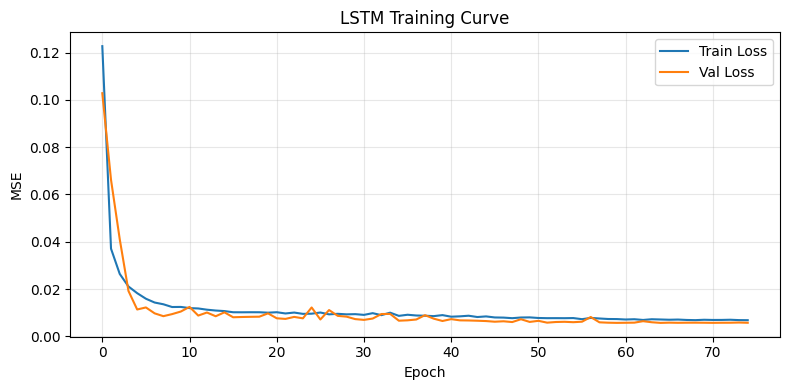

✓ Method C completed


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10: METHOD C — Hybrid LSTM
# Features include Physics_Power as an additional input so the LSTM can
# learn to "correct" the physical model with data-driven residuals.
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("METHOD C: Hybrid LSTM  (Physics + Weather → Power)")
print("="*60)
 
# Physics power computed purely from weather (same info as Method A)
train_all["Physics_Power"] = physics_power(
    train_all["GHI"].values,    # NOTE: GHI is the TARGET of Stage-1;
    train_all["Temperature"].values  # using it here gives the UPPER BOUND
    # of what physics can contribute.  Replace with ghi_pred_b if you
    # want a strict no-leakage variant.
)
test_all["Physics_Power"] = physics_power(
    test_all["GHI"].values,
    test_all["Temperature"].values,
)
 
FEATURES_C = [
    "Physics_Power",
    "Temperature", "Humidity", "WindSpeed", "Pressure",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
]
SEQ_LEN = 24   # look-back window (hours)
 
# Scale
scaler_X_c = MinMaxScaler()
scaler_y_c = MinMaxScaler()
 
train_c = train_all.copy()
test_c  = test_all.copy()
 
train_c[FEATURES_C] = scaler_X_c.fit_transform(train_all[FEATURES_C])
test_c [FEATURES_C] = scaler_X_c.transform(test_all[FEATURES_C])
train_c[TARGET]     = scaler_y_c.fit_transform(train_all[[TARGET]])
test_c [TARGET]     = scaler_y_c.transform(test_all[[TARGET]])
 
def make_sequences(data, features, target, seq_len):
    data = data.sort_index()
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[features].iloc[i : i + seq_len].values)
        y.append(data[target].iloc[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
X_train_c, y_train_c = make_sequences(train_c, FEATURES_C, TARGET, SEQ_LEN)
X_test_c,  y_test_c  = make_sequences(test_c,  FEATURES_C, TARGET, SEQ_LEN)
 
print(f"  LSTM shapes  train={X_train_c.shape}  test={X_test_c.shape}")
 
# ── Model architecture ──────────────────────────────────────────────────────
tf.random.set_seed(42)
 
model_c = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURES_C))),
 
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),
 
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.3),
 
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1),
])
model_c.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model_c.summary()
 
callbacks_c = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, verbose=0),
]
 
history_c = model_c.fit(
    X_train_c, y_train_c,
    validation_split=0.15,
    epochs=80,
    batch_size=64,
    callbacks=callbacks_c,
    verbose=1,
)
 
# ── Predict + inverse-scale ──────────────────────────────────────────────────
y_raw_c    = model_c.predict(X_test_c, verbose=0)
y_pred_c   = scaler_y_c.inverse_transform(y_raw_c).flatten()
y_pred_c   = np.maximum(y_pred_c, 0)
 
# Align true labels (seq_len offset)
y_test_c_true = test_all[TARGET].values[SEQ_LEN:]   # drop first SEQ_LEN rows
 
metrics_c = calculate_metrics(y_test_c_true, y_pred_c, "Method C — Hybrid BiLSTM")
 
# Training curve
plt.figure(figsize=(8,4))
plt.plot(history_c.history["loss"],     label="Train Loss")
plt.plot(history_c.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("LSTM Training Curve")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_training.png", dpi=150)
plt.show()
print("✓ Method C completed")

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11: Persistence Baseline
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("PERSISTENCE BASELINE  (naive: ŷ(t) = y(t-24))")
print("="*60)
 
y_true_all      = test_all[TARGET].values
y_persist       = test_all[TARGET].shift(24).values    # 24-hour lag
valid_mask      = ~np.isnan(y_persist)
y_persist_clean = y_persist[valid_mask]
y_true_persist  = y_true_all[valid_mask]
 
metrics_persist = calculate_metrics(y_true_persist, y_persist_clean, "Persistence Baseline")
print("✓ Baseline computed")
 
 


PERSISTENCE BASELINE  (naive: ŷ(t) = y(t-24))

────────────────────────────────────────
  Persistence Baseline
────────────────────────────────────────
  RMSE   : 3542.36 W
  nRMSE  : 46.82 %
  MAE    : 2877.56 W
  MBE    : -2752.20 W
  R²     : -1.9522
✓ Baseline computed


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12: Statistical Comparison — Diebold-Mariano Tests
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("STATISTICAL COMPARISON (Diebold-Mariano Test)")
print("="*60)
 
# Align all predictions to the shortest common length
# Method C is offset by SEQ_LEN rows
offset = SEQ_LEN
 
y_true_dm = test_all[TARGET].values[offset:]
y_a_dm    = y_pred_a[offset:]
y_b_dm    = y_pred_b[offset:]
y_c_dm    = y_pred_c                  # already aligned to offset
 
min_len = min(len(y_true_dm), len(y_a_dm), len(y_b_dm), len(y_c_dm))
y_true_dm = y_true_dm[:min_len]
y_a_dm    = y_a_dm[:min_len]
y_b_dm    = y_b_dm[:min_len]
y_c_dm    = y_c_dm[:min_len]
 
pairs = [
    ("A vs B", y_a_dm, y_b_dm),
    ("A vs C", y_a_dm, y_c_dm),
    ("B vs C", y_b_dm, y_c_dm),
]
 
dm_results = []
print(f"\n{'Comparison':<12} {'DM Stat':>10} {'p-value':>10} {'Significant?':>14}")
print("─" * 50)
for label, p1, p2 in pairs:
    dm, pv = diebold_mariano_test(y_true_dm, p1, p2)
    sig    = "YES ✓" if pv < 0.05 else "NO"
    print(f"{label:<12} {dm:>10.4f} {pv:>10.4f} {sig:>14}")
    dm_results.append({"Comparison": label, "DM": dm, "p": pv, "Sig": sig})
 
print("\nNote: Significant (p < 0.05) means the two methods differ reliably.")
print("✓ DM tests completed")
 
 


STATISTICAL COMPARISON (Diebold-Mariano Test)

Comparison      DM Stat    p-value   Significant?
──────────────────────────────────────────────────
A vs B           4.7258     0.0000          YES ✓
A vs C         -22.0184     0.0000          YES ✓
B vs C         -23.2248     0.0000          YES ✓

Note: Significant (p < 0.05) means the two methods differ reliably.
✓ DM tests completed


FINAL RESULTS SUMMARY
                      Method    RMSE (W)  nRMSE (%)     MAE (W)      MBE (W)        R²
      Persistence (Baseline) 3542.357912  46.821321 2877.555511 -2752.204611 -1.952243
   Method A — Direct XGBoost  879.957083  11.630884  662.190985    92.181379  0.818069
Method B — Two-Stage Physics  848.388616  11.213626  650.467663   111.270196  0.830889
    Method C — Hybrid BiLSTM 1319.138130  17.435785  992.829656  -473.696519  0.590600


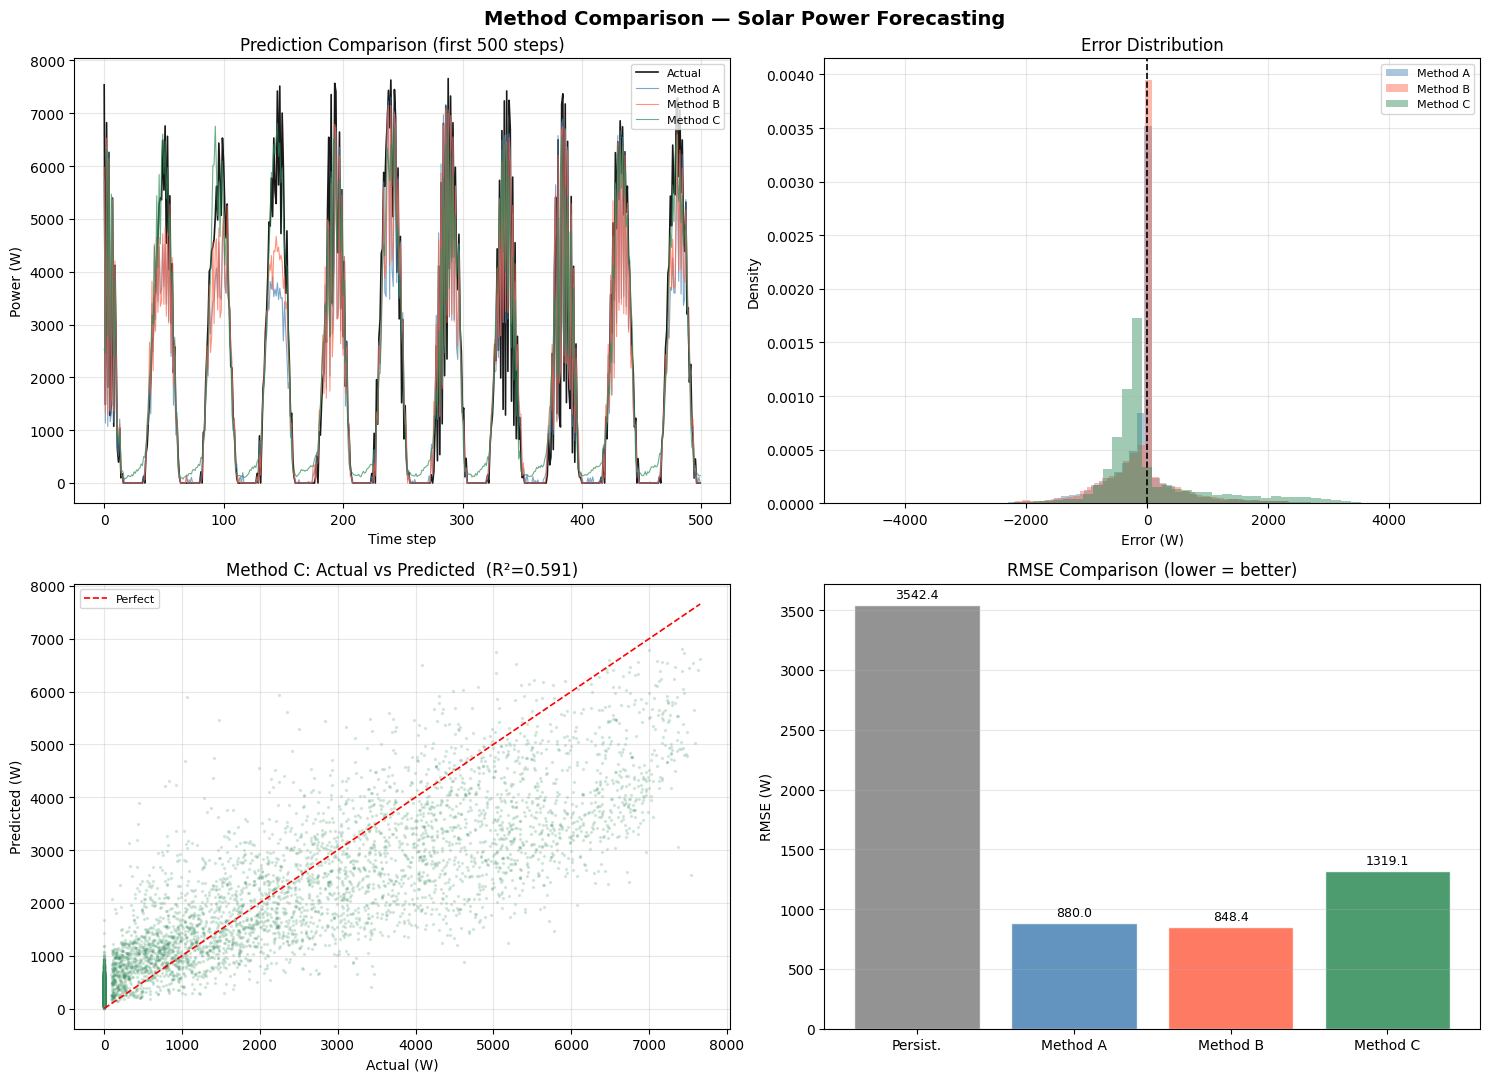


✓ Figure saved: final_comparison.png
✓ Results saved: results_summary.csv


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13: Final Comparison — Table + Visualisations
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
 
results_df = pd.DataFrame({
    "Method": [
        "Persistence (Baseline)",
        "Method A — Direct XGBoost",
        "Method B — Two-Stage Physics",
        "Method C — Hybrid BiLSTM",
    ],
    "RMSE (W)":  [
        metrics_persist["RMSE (W)"],
        metrics_a["RMSE (W)"],
        metrics_b["RMSE (W)"],
        metrics_c["RMSE (W)"],
    ],
    "nRMSE (%)": [
        metrics_persist["nRMSE (%)"],
        metrics_a["nRMSE (%)"],
        metrics_b["nRMSE (%)"],
        metrics_c["nRMSE (%)"],
    ],
    "MAE (W)":   [
        metrics_persist["MAE (W)"],
        metrics_a["MAE (W)"],
        metrics_b["MAE (W)"],
        metrics_c["MAE (W)"],
    ],
    "MBE (W)":   [
        metrics_persist["MBE (W)"],
        metrics_a["MBE (W)"],
        metrics_b["MBE (W)"],
        metrics_c["MBE (W)"],
    ],
    "R²":        [
        metrics_persist["R2"],
        metrics_a["R2"],
        metrics_b["R2"],
        metrics_c["R2"],
    ],
})
 
print(results_df.to_string(index=False))
results_df.to_csv("results_summary.csv", index=False)
 
# ── 4-panel comparison figure ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Method Comparison — Solar Power Forecasting", fontsize=14, fontweight="bold")
 
# 1. Time-series (first 500 daytime points)
N = 500
axes[0,0].plot(y_true_dm[:N],  label="Actual",   lw=1.2, color="black",     alpha=0.9)
axes[0,0].plot(y_a_dm[:N],     label="Method A",  lw=0.8, color="steelblue", alpha=0.7)
axes[0,0].plot(y_b_dm[:N],     label="Method B",  lw=0.8, color="tomato",    alpha=0.7)
axes[0,0].plot(y_c_dm[:N],     label="Method C",  lw=0.8, color="seagreen",  alpha=0.7)
axes[0,0].set(xlabel="Time step", ylabel="Power (W)",
              title="Prediction Comparison (first 500 steps)")
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)
 
# 2. Error distribution
for y_pred, label, color in [
    (y_a_dm, "Method A", "steelblue"),
    (y_b_dm, "Method B", "tomato"),
    (y_c_dm, "Method C", "seagreen"),
]:
    err = y_true_dm - y_pred
    axes[0,1].hist(err, bins=60, alpha=0.45, label=label, color=color, density=True)
axes[0,1].axvline(0, color="black", lw=1.2, ls="--")
axes[0,1].set(xlabel="Error (W)", ylabel="Density", title="Error Distribution")
axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)
 
# 3. Scatter — best method (C)
axes[1,0].scatter(y_true_dm, y_c_dm, alpha=0.15, s=2, color="seagreen")
lim = max(y_true_dm.max(), y_c_dm.max())
axes[1,0].plot([0, lim], [0, lim], "r--", lw=1.2, label="Perfect")
axes[1,0].set(xlabel="Actual (W)", ylabel="Predicted (W)",
              title=f"Method C: Actual vs Predicted  (R²={metrics_c['R2']:.3f})")
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)
 
# 4. Bar chart — metrics
methods = ["Persist.", "Method A", "Method B", "Method C"]
rmse_vals  = [metrics_persist["RMSE (W)"],
              metrics_a["RMSE (W)"], metrics_b["RMSE (W)"], metrics_c["RMSE (W)"]]
colors = ["grey", "steelblue", "tomato", "seagreen"]
bars = axes[1,1].bar(methods, rmse_vals, color=colors, alpha=0.85, edgecolor="white")
axes[1,1].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
axes[1,1].set(ylabel="RMSE (W)", title="RMSE Comparison (lower = better)")
axes[1,1].grid(alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Figure saved: final_comparison.png")
print("✓ Results saved: results_summary.csv")
 
 

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14: Per-Location Breakdown
# ─────────────────────────────────────────────────────────────────────────────
 
print("="*60)
print("PER-LOCATION BREAKDOWN")
print("="*60)
 
# Align test_all to the DM offset window for fair comparison
test_aligned = test_all.iloc[offset:offset + min_len].copy()
test_aligned["y_pred_a"] = y_a_dm
test_aligned["y_pred_b"] = y_b_dm
test_aligned["y_pred_c"] = y_c_dm
 
for loc in test_aligned["Location"].unique():
    sub = test_aligned[test_aligned["Location"] == loc]
    yt  = sub[TARGET].values
    print(f"\n── {loc} ({len(sub):,} samples) ──")
    for col, name in [("y_pred_a","A"),("y_pred_b","B"),("y_pred_c","C")]:
        r = np.sqrt(mean_squared_error(yt[yt>10], sub[col].values[yt>10]))
        r2= r2_score(yt[yt>10], sub[col].values[yt>10])
        print(f"   Method {name}: RMSE={r:.1f} W   R²={r2:.4f}")
 
 

PER-LOCATION BREAKDOWN

── Phoenix (4,404 samples) ──
   Method A: RMSE=958.4 W   R²=0.7985
   Method B: RMSE=940.5 W   R²=0.8060
   Method C: RMSE=1653.4 W   R²=0.4003

── Berlin (4,404 samples) ──
   Method A: RMSE=786.9 W   R²=0.7362
   Method B: RMSE=738.3 W   R²=0.7677
   Method C: RMSE=833.0 W   R²=0.7043
